# KNN-Based Selection Within Strata

**Strategy**: Within-cell KNN matching on experience with c:1 ratio
1. Filter SOEP to cells with n_obs >= 5
2. Filter LinkedIn to matched cells
3. For each cell, select $n^{LI}_{s} = \min(N^{LI}_{s}, c \cdot N^{SOEP}_{s})$ LinkedIn observations
4. Use KNN to select LinkedIn observations closest to SOEP in experience space (when N_LI > c * N_SOEP)
5. Initially set c = 3 (MATCHES_PER_SOEP parameter)

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.neighbors import NearestNeighbors

# Import path configurations
import sys
sys.path.insert(0, str(Path.cwd().parent.parent))
from bonn_thesis.config import MERGED_EXP_ED_SAMPLING_BLD, SOEP_DATA_BLD, BLD

## Configuration

Parameters for cell filtering and matching.

In [11]:
# Sampling parameters
MIN_SOEP_OBS = 5  # Minimum SOEP observations per cell
MIN_LINKEDIN_OBS = 5  # Minimum LinkedIn observations per cell
MATCHES_PER_SOEP = 3  # Number of LinkedIn matches per SOEP observation (c parameter)
RANDOM_STATE = 42  # For reproducibility

print(f"Configuration:")
print(f"  Minimum SOEP observations per cell: {MIN_SOEP_OBS}")
print(f"  Minimum LinkedIn observations per cell: {MIN_LINKEDIN_OBS}")
print(f"  Matches per SOEP observation (c): {MATCHES_PER_SOEP}")
print(f"  Random state: {RANDOM_STATE}")

Configuration:
  Minimum SOEP observations per cell: 5
  Minimum LinkedIn observations per cell: 5
  Matches per SOEP observation (c): 3
  Random state: 42


## Step 1: Load SOEP Data

In [12]:
# Load SOEP clean data
soep_file = SOEP_DATA_BLD / "soep_clean.parquet"
soep_all = pd.read_parquet(soep_file, engine="fastparquet")

# Remove observations with missing values in pgexpft
soep_all = soep_all.dropna(subset=["pgexpft"])

## Step 2: Filter SOEP to Cells with n_obs >= 5

In [13]:
# Count observations per cell in SOEP
soep_cell_counts = soep_all.groupby(
    ['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en']
).size().reset_index(name='n_obs')

# Filter to cells with at least MIN_SOEP_OBS observations
soep_cells_filtered = soep_cell_counts[soep_cell_counts['n_obs'] >= MIN_SOEP_OBS].copy()

In [14]:
# Filter SOEP data to include only these cells
soep_filtered = soep_all.merge(
    soep_cells_filtered[['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en']],
    on=['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en'],
    how='inner'
)

## Step 3: Load LinkedIn Data

In [15]:
# Find all LinkedIn strata files
all_files = sorted(MERGED_EXP_ED_SAMPLING_BLD.glob("linkedin_merged_exp_ed_strata_*.parquet"))
n_files = len(all_files)
print(f"Loading {n_files} LinkedIn files...")

# Concatenate all files
dfs = []
for i, file in enumerate(all_files, 1):
    if i % 50 == 0 or i == n_files:
        print(f"  Loaded {i}/{n_files} files...")
    df = pd.read_parquet(file)
    dfs.append(df)

linkedin_all = pd.concat(dfs, ignore_index=True)
print(f"\nLoaded {len(linkedin_all):,} total LinkedIn observations")

Loading 563 LinkedIn files...
  Loaded 50/563 files...
  Loaded 100/563 files...
  Loaded 150/563 files...
  Loaded 200/563 files...
  Loaded 250/563 files...
  Loaded 300/563 files...
  Loaded 350/563 files...
  Loaded 400/563 files...
  Loaded 450/563 files...
  Loaded 500/563 files...
  Loaded 550/563 files...
  Loaded 563/563 files...

Loaded 1,855,962 total LinkedIn observations


In [16]:
linkedin_all

,exp_id,prof_id,comp_id,industry_id,job_title_id,job_title,exp_description,exp_company,industry,matched_city,...,isco_2_digit,isco_1_digit,isco_1_name,isco_2_name,isco_3_name,sex_en,state_en,state_de,custom_id,soep_n_obs
0,9,3,9,4.0,8.0,Banking Supervisor,Supervision of the largest bank in a Southern ...,European Central Bank,Banking,Frankfurt,...,33,3,Technicians and Associate Professionals,Business and Administration Associate Professi...,Financial and Mathematical Associate Professio...,male,Hesse,Hessen,None,NaN
1,10,3,9,4.0,9.0,Adviser,Adviser in the Planning and Coordination of Su...,European Central Bank,Banking,Frankfurt,...,33,3,Technicians and Associate Professionals,Business and Administration Associate Professi...,Financial and Mathematical Associate Professio...,male,Hesse,Hessen,None,NaN
2,126,25,83,4.0,104.0,Vice President,Filialdirektor,UniCredit,Banking,Frankenthal,...,12,1,Managers,Administrative and Commercial Managers,Business Services and Administration Managers,male,Rhineland-Palatinate,Rheinland-Pfalz,None,NaN
3,126,25,83,4.0,104.0,Vice President,Filialdirektor,UniCredit,Banking,Frankenthal,...,12,1,Managers,Administrative and Commercial Managers,Business Services and Administration Managers,male,Rhineland-Palatinate,Rheinland-Pfalz,None,NaN
4,126,25,83,4.0,104.0,Vice President,Filialdirektor,UniCredit,Banking,Frankenthal,...,12,1,Managers,Administrative and Commercial Managers,Business Services and Administration Managers,male,Rhineland-Palatinate,Rheinland-Pfalz,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1855957,20674478,5627909,690,3.0,3735251.0,Electronics Maintenance,None,Ford Motor Company,Automotive,Köln,...,74,7,Craft and Related Trades Workers,Electrical and Electronics Trades Workers,Electronics and Telecommunications Installers ...,male,North Rhine-Westphalia,Nordrhein-Westfalen,wage_soep_exp_15_20140,5.0
1855958,20674478,5627909,690,3.0,3735251.0,Electronics Maintenance,None,Ford Motor Company,Automotive,Köln,...,74,7,Craft and Related Trades Workers,Electrical and Electronics Trades Workers,Electronics and Telecommunications Installers ...,male,North Rhine-Westphalia,Nordrhein-Westfalen,wage_soep_exp_15_24051,4.0
1855959,20674502,5627919,57516,9.0,135954.0,Real Estate Asset Manager,2010 - 2017 selbständige Immobilienvermarktung...,KGAL GmbH & Co. KG (KGAL),Financial Services,München,...,33,3,Technicians and Associate Professionals,Business and Administration Associate Professi...,Financial and Mathematical Associate Professio...,female,Bavaria,Bayern,None,NaN
1855960,20674502,5627919,57516,9.0,135954.0,Real Estate Asset Manager,2010 - 2017 selbständige Immobilienvermarktung...,KGAL GmbH & Co. KG (KGAL),Financial Services,München,...,33,3,Technicians and Associate Professionals,Business and Administration Associate Professi...,Financial and Mathematical Associate Professio...,female,Bavaria,Bayern,None,NaN


## Step 4: Filter LinkedIn to Matched Cells Only

In [58]:
# Keep only LinkedIn observations with custom_id (matched to SOEP)
linkedin_matched = linkedin_all[linkedin_all['custom_id'].notna()].copy()

print(f"LinkedIn observations with SOEP match: {len(linkedin_matched):,}")
print(f"LinkedIn observations without match: {linkedin_all['custom_id'].isna().sum():,}")
print(f"Match rate: {len(linkedin_matched) / len(linkedin_all) * 100:.1f}%")

# Filter to cells that meet minimum SOEP size criteria
linkedin_in_filtered_cells = linkedin_matched.merge(
    soep_cells_filtered[['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en']],
    on=['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en'],
    how='inner'
)

print(f"\nLinkedIn in filtered cells (n_obs >= {MIN_SOEP_OBS}): {len(linkedin_in_filtered_cells):,}")

LinkedIn observations with SOEP match: 1,275,125
LinkedIn observations without match: 580,837
Match rate: 68.7%

LinkedIn in filtered cells (n_obs >= 5): 371,168


## Step 5: Filter to Cells with Sufficient LinkedIn Observations

In [59]:
# Count LinkedIn observations per cell
linkedin_cell_counts = linkedin_in_filtered_cells.groupby(
    ['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en']
).size().reset_index(name='linkedin_count')

print(f"LinkedIn observations per cell:")
print(f"  Total cells: {len(linkedin_cell_counts)}")
print(f"  Distribution:")
print(linkedin_cell_counts['linkedin_count'].describe())

# Filter to cells with at least 5 LinkedIn observations
MIN_LINKEDIN_OBS = 5
linkedin_cells_sufficient = linkedin_cell_counts[
    linkedin_cell_counts['linkedin_count'] >= MIN_LINKEDIN_OBS
].copy()

print(f"\nCells with at least {MIN_LINKEDIN_OBS} LinkedIn observations: {len(linkedin_cells_sufficient)}")
print(f"Total LinkedIn observations in sufficient cells: {linkedin_cells_sufficient['linkedin_count'].sum():,}")

LinkedIn observations per cell:
  Total cells: 2621
  Distribution:
count    2621.000000
mean      141.613125
std       448.893886
min         1.000000
25%         3.000000
50%        13.000000
75%        70.000000
max      5644.000000
Name: linkedin_count, dtype: float64

Cells with at least 5 LinkedIn observations: 1721
Total LinkedIn observations in sufficient cells: 369,341


## Step 6: Re-filter Both Datasets to Double-Sufficient Cells

Ensure both SOEP and LinkedIn have at least 5 observations per cell.

In [60]:
# Get cells that meet BOTH criteria (>=5 SOEP AND >=5 LinkedIn)
double_sufficient_cells = linkedin_cells_sufficient[
    ['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en']
]

# Re-filter SOEP to only these cells
soep_final = soep_filtered.merge(
    double_sufficient_cells,
    on=['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en'],
    how='inner'
).reset_index(drop=True)

# Re-filter LinkedIn to only these cells
linkedin_pool = linkedin_in_filtered_cells.merge(
    double_sufficient_cells,
    on=['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en'],
    how='inner'
).reset_index(drop=True)

print(f"Double-filtered datasets (both >= 5 obs per cell):")
print(f"  Unique cells: {len(double_sufficient_cells)}")
print(f"  SOEP: {len(soep_final):,} observations")
print(f"  LinkedIn (pool): {len(linkedin_pool):,} observations")
print(f"\nRemoved from SOEP: {len(soep_filtered) - len(soep_final):,} observations")
print(f"Removed from LinkedIn: {len(linkedin_in_filtered_cells) - len(linkedin_pool):,} observations")

Double-filtered datasets (both >= 5 obs per cell):
  Unique cells: 1721
  SOEP: 17,341 observations
  LinkedIn (pool): 369,341 observations

Removed from SOEP: 14,513 observations
Removed from LinkedIn: 1,827 observations


## Step 7: KNN-Based Selection Within Cells

For each cell (stratum), select $n^{LI}_{s} = \min(N^{LI}_{s}, c \cdot N^{SOEP}_{s})$ LinkedIn observations using KNN matching on experience.

In [ ]:
def knn_select_within_cells(linkedin_df, soep_df, cell_cols, matches_per_soep=3, random_state=42):
    """
    Select LinkedIn observations using KNN matching within each cell.
    
    For each cell, select n^{LI}_{s} = min(N^{LI}_{s}, c * N^{SOEP}_{s}) observations
    where c = matches_per_soep.
    
    Strategy:
    - If N^{LI}_{s} <= c * N^{SOEP}_{s}: select all LinkedIn observations
    - Otherwise: use KNN to find the c * N^{SOEP}_{s} LinkedIn observations closest 
                 to any SOEP observation in experience space
    
    Args:
        linkedin_df: LinkedIn dataframe with pgexpft column
        soep_df: SOEP dataframe with pgexpft column  
        cell_cols: List of columns defining cells (strata)
        matches_per_soep: Target ratio of LinkedIn to SOEP observations (c parameter)
        random_state: Random seed for reproducibility
        
    Returns:
        Tuple of (selected_linkedin_df, selection_metadata_dict)
    """
    np.random.seed(random_state)
    
    # Initialize lists for results
    selected_dfs = []
    metadata = {
        'cells_processed': 0,
        'cells_all_selected': 0,  # N_LI <= c * N_SOEP
        'cells_knn_applied': 0,   # N_LI > c * N_SOEP
        'cells_with_issues': 0,
        'total_soep': 0,
        'total_linkedin_before': 0,
        'total_linkedin_after': 0,
        'issue_log': []
    }
    
    # Get unique cells
    unique_cells = soep_df[cell_cols].drop_duplicates()
    
    for idx, cell_row in unique_cells.iterrows():
        metadata['cells_processed'] += 1
        
        # Create cell mask
        cell_mask_soep = True
        cell_mask_linkedin = True
        for col in cell_cols:
            cell_mask_soep &= (soep_df[col] == cell_row[col])
            cell_mask_linkedin &= (linkedin_df[col] == cell_row[col])
        
        # Extract cell data
        soep_cell = soep_df[cell_mask_soep].copy()
        linkedin_cell = linkedin_df[cell_mask_linkedin].copy()
        
        # Remove missing pgexpft
        soep_cell = soep_cell[soep_cell['pgexpft'].notna()].copy()
        linkedin_cell = linkedin_cell[linkedin_cell['pgexpft'].notna()].copy()
        
        n_soep = len(soep_cell)
        n_linkedin = len(linkedin_cell)
        
        metadata['total_soep'] += n_soep
        metadata['total_linkedin_before'] += n_linkedin
        
        # Skip if insufficient data
        if n_soep == 0 or n_linkedin == 0:
            metadata['cells_with_issues'] += 1
            metadata['issue_log'].append({
                'cell': cell_row.to_dict(),
                'reason': 'no_data',
                'soep_n': n_soep,
                'linkedin_n': n_linkedin
            })
            continue
        
        # Calculate target sample size: n^{LI}_{s} = min(N^{LI}_{s}, c * N^{SOEP}_{s})
        target_linkedin_size = min(n_linkedin, matches_per_soep * n_soep)
        
        # Case 1: Select all LinkedIn observations (N_LI <= c * N_SOEP)
        if n_linkedin <= matches_per_soep * n_soep:
            selected_dfs.append(linkedin_cell)
            metadata['total_linkedin_after'] += n_linkedin
            metadata['cells_all_selected'] += 1
        
        # Case 2: Apply KNN to select subset (N_LI > c * N_SOEP)
        else:
            # Prepare experience data
            soep_exp = soep_cell[['pgexpft']].values
            linkedin_exp = linkedin_cell[['pgexpft']].values
            
            # Fit KNN model on SOEP observations
            # We'll find the closest LinkedIn obs to each SOEP obs
            knn = NearestNeighbors(n_neighbors=min(n_linkedin, matches_per_soep), 
                                   metric='euclidean')
            knn.fit(linkedin_exp)
            
            # Find k nearest LinkedIn neighbors for each SOEP observation
            distances, indices = knn.kneighbors(soep_exp)
            
            # Flatten indices to get all matched LinkedIn observations
            matched_linkedin_indices = np.unique(indices.flatten())
            
            # If we have more matches than needed, sample randomly
            if len(matched_linkedin_indices) > target_linkedin_size:
                np.random.seed(random_state + idx)
                matched_linkedin_indices = np.random.choice(
                    matched_linkedin_indices, 
                    size=target_linkedin_size, 
                    replace=False
                )
            
            # Select the LinkedIn observations
            selected_linkedin = linkedin_cell.iloc[matched_linkedin_indices].copy()
            selected_dfs.append(selected_linkedin)
            metadata['total_linkedin_after'] += len(selected_linkedin)
            metadata['cells_knn_applied'] += 1
    
    # Concatenate all selected cells
    if selected_dfs:
        linkedin_selected = pd.concat(selected_dfs, ignore_index=True)
    else:
        linkedin_selected = pd.DataFrame(columns=linkedin_df.columns)
    
    return linkedin_selected, metadata

print("KNN selection function defined.")

KNN selection function defined.


In [62]:
# Apply KNN-based selection within cells
cell_cols = ['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en']

print("Starting KNN-based selection...")
print(f"  Before selection: LinkedIn has {len(linkedin_pool):,} observations")
print(f"  Strategy: n^{{LI}}_{{s}} = min(N^{{LI}}_{{s}}, {MATCHES_PER_SOEP} × N^{{SOEP}}_{{s}})")
print(f"  Maximum expected size: ~{len(soep_final) * MATCHES_PER_SOEP:,} LinkedIn observations")

linkedin_pool_selected, selection_metadata = knn_select_within_cells(
    linkedin_df=linkedin_pool,
    soep_df=soep_final,
    cell_cols=cell_cols,
    matches_per_soep=MATCHES_PER_SOEP,
    random_state=RANDOM_STATE
)

print(f"\nSelection complete!")
print(f"  Cells processed: {selection_metadata['cells_processed']}")
print(f"  Cells with all LinkedIn selected: {selection_metadata['cells_all_selected']}")
print(f"  Cells with KNN applied: {selection_metadata['cells_knn_applied']}")
print(f"  Cells with issues: {selection_metadata['cells_with_issues']}")
print(f"\n  LinkedIn observations:")
print(f"    Before: {selection_metadata['total_linkedin_before']:,}")
print(f"    After: {selection_metadata['total_linkedin_after']:,}")
change = selection_metadata['total_linkedin_after'] - selection_metadata['total_linkedin_before']
if change > 0:
    print(f"    Increase: +{change:,} ({(selection_metadata['total_linkedin_after']/selection_metadata['total_linkedin_before'] - 1)*100:.1f}%)")
else:
    print(f"    Reduction: {change:,} ({(1 - selection_metadata['total_linkedin_after']/selection_metadata['total_linkedin_before'])*100:.1f}%)")
print(f"  Actual ratio: {selection_metadata['total_linkedin_after'] / selection_metadata['total_soep']:.2f} LinkedIn per SOEP")

if selection_metadata['cells_with_issues'] > 0:
    print(f"\n  Issue breakdown:")
    issue_types = {}
    for issue in selection_metadata['issue_log']:
        reason = issue['reason']
        issue_types[reason] = issue_types.get(reason, 0) + 1
    for reason, count in issue_types.items():
        print(f"    {reason}: {count} cells")

Starting KNN-based selection...
  Before selection: LinkedIn has 369,341 observations
  Strategy: n^{LI}_{s} = min(N^{LI}_{s}, 3 × N^{SOEP}_{s})
  Maximum expected size: ~52,023 LinkedIn observations

Selection complete!
  Cells processed: 1721
  Cells with all LinkedIn selected: 719
  Cells with KNN applied: 1002
  Cells with issues: 0

  LinkedIn observations:
    Before: 369,341
    After: 29,178
    Reduction: -340,163 (92.1%)
  Actual ratio: 1.68 LinkedIn per SOEP


## Step 8: Validate Selection Quality

Compare experience distributions before and after KNN-based selection.

In [63]:
def calculate_smd(treated_values, control_values):
    """Calculate Standardized Mean Difference (SMD)."""
    mean_treated = np.mean(treated_values)
    mean_control = np.mean(control_values)
    var_treated = np.var(treated_values, ddof=1)
    var_control = np.var(control_values, ddof=1)
    pooled_std = np.sqrt((var_treated + var_control) / 2)
    smd = (mean_treated - mean_control) / pooled_std
    return smd

# Calculate SMD before and after selection
soep_exp = soep_final['pgexpft'].dropna()
linkedin_exp_before = linkedin_pool['pgexpft'].dropna()
linkedin_exp_after = linkedin_pool_selected['pgexpft'].dropna()

smd_before = calculate_smd(soep_exp, linkedin_exp_before)
smd_after = calculate_smd(soep_exp, linkedin_exp_after)

print("=== Experience Distribution Comparison ===\n")
print(f"{'Dataset':<25} {'Mean':>10} {'Std':>10} {'Min':>10} {'Median':>10} {'Max':>10}")
print("-" * 80)
print(f"{'SOEP (target)':<25} {soep_exp.mean():>10.2f} {soep_exp.std():>10.2f} {soep_exp.min():>10.2f} {soep_exp.median():>10.2f} {soep_exp.max():>10.2f}")
print(f"{'LinkedIn (before)':<25} {linkedin_exp_before.mean():>10.2f} {linkedin_exp_before.std():>10.2f} {linkedin_exp_before.min():>10.2f} {linkedin_exp_before.median():>10.2f} {linkedin_exp_before.max():>10.2f}")
print(f"{'LinkedIn (after KNN)':<25} {linkedin_exp_after.mean():>10.2f} {linkedin_exp_after.std():>10.2f} {linkedin_exp_after.min():>10.2f} {linkedin_exp_after.median():>10.2f} {linkedin_exp_after.max():>10.2f}")

print(f"\n=== Standardized Mean Difference (SMD) ===")
print(f"Before selection: {smd_before:.4f}")
print(f"After selection:  {smd_after:.4f}")
print(f"Change:          {abs(smd_after) - abs(smd_before):.4f}")
print(f"\nInterpretation:")
print(f"  |SMD| < 0.1: Good balance ✓")
print(f"  |SMD| < 0.25: Acceptable balance")
print(f"  |SMD| >= 0.25: Imbalance")
print(f"\nResult: {'✓ Good balance achieved' if abs(smd_after) < 0.1 else 'Acceptable balance' if abs(smd_after) < 0.25 else '⚠ Some imbalance remains'}")

=== Experience Distribution Comparison ===

Dataset                         Mean        Std        Min     Median        Max
--------------------------------------------------------------------------------
SOEP (target)                  19.00      11.57       0.00      18.83      58.58
LinkedIn (before)               8.86       7.11       0.08       7.01      64.42
LinkedIn (after KNN)           10.96       9.65       0.08       8.08      48.58

=== Standardized Mean Difference (SMD) ===
Before selection: 1.0571
After selection:  0.7551
Change:          -0.3020

Interpretation:
  |SMD| < 0.1: Good balance ✓
  |SMD| < 0.25: Acceptable balance
  |SMD| >= 0.25: Imbalance

Result: ⚠ Some imbalance remains


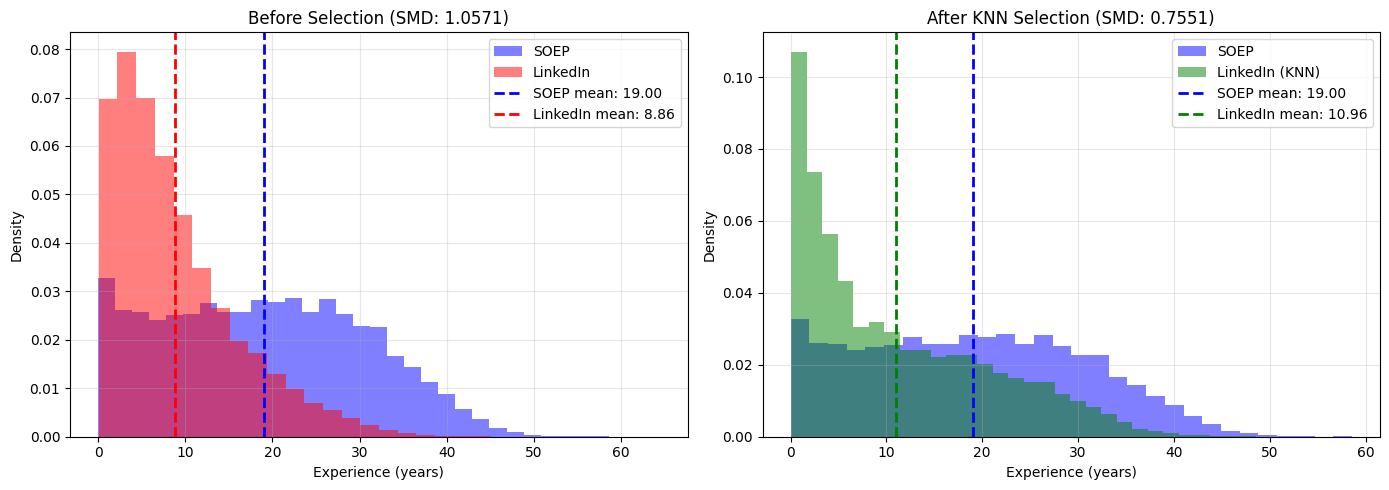

In [64]:
# Visualize distribution comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before selection
axes[0].hist(soep_exp, bins=30, alpha=0.5, label='SOEP', density=True, color='blue')
axes[0].hist(linkedin_exp_before, bins=30, alpha=0.5, label='LinkedIn', density=True, color='red')
axes[0].axvline(soep_exp.mean(), color='blue', linestyle='--', linewidth=2, label=f'SOEP mean: {soep_exp.mean():.2f}')
axes[0].axvline(linkedin_exp_before.mean(), color='red', linestyle='--', linewidth=2, label=f'LinkedIn mean: {linkedin_exp_before.mean():.2f}')
axes[0].set_xlabel('Experience (years)')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Before Selection (SMD: {smd_before:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# After selection
axes[1].hist(soep_exp, bins=30, alpha=0.5, label='SOEP', density=True, color='blue')
axes[1].hist(linkedin_exp_after, bins=30, alpha=0.5, label='LinkedIn (KNN)', density=True, color='green')
axes[1].axvline(soep_exp.mean(), color='blue', linestyle='--', linewidth=2, label=f'SOEP mean: {soep_exp.mean():.2f}')
axes[1].axvline(linkedin_exp_after.mean(), color='green', linestyle='--', linewidth=2, label=f'LinkedIn mean: {linkedin_exp_after.mean():.2f}')
axes[1].set_xlabel('Experience (years)')
axes[1].set_ylabel('Density')
axes[1].set_title(f'After KNN Selection (SMD: {smd_after:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()